En esta libreta se experimenta con técnicas de clustering para el conjunto de datos definidos en la libreta [`notebooks/data_integration.ipynb`](../data_integration.ipynb). Este dataset integra las diferentes fuentes de datos disponibles, combinando variables delictivas y socoioeconómicas a nivel municipio-año. 

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# config

In [23]:
# sklearn imports
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline, make_pipeline

Definimos las rutas al archivo para el modelado: 

In [4]:
# data
base_dir = Path().resolve().parents[1]

data_dir = base_dir / "data"

processed_dir = data_dir / "processed"

dataset_modeling_path = processed_dir / "dataset_model.csv"
assert dataset_modeling_path.exists() and dataset_modeling_path.is_file()

Cargamos del dataset para modelado: 

In [5]:
df = pd.read_csv(dataset_modeling_path)
df.head()

,anio,clave_entidad,clave_municipio,entidad,municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0,10.0,1.1
1,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6,11.5,3.0
2,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2,9.0,3.4
3,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1,6.6,7.4
4,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4,7.7,16.2


In [6]:
df.describe()

,anio,clave_entidad,clave_municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos
count,78056.000000,78056.000000,78056.000000,78056.000000,7.805600e+04,77941.000000,77941.000000,77941.000000,77941.000000,77941.000000,77941.000000,77805.000000,77805.000000,77805.000000,77805.000000
mean,2020.188314,19.220303,19322.748732,832.432869,1.870950e+06,54.053062,9.970873,3.208026,1.480639,26.382966,81.809561,64.132846,20.150873,3.692491,43.345273
std,3.087723,7.498107,7513.476982,3408.658862,8.868006e+05,3.908549,7.523756,5.377598,2.796400,10.568468,11.845122,21.194031,18.049221,3.829613,30.016250
min,2015.000000,1.000000,1001.000000,0.000000,1.100100e+04,21.406635,0.353446,0.000000,0.000000,3.950392,28.453113,2.700000,0.000000,0.000000,0.000000
25%,2018.000000,14.000000,14058.000000,13.000000,1.414058e+06,51.968644,4.347826,0.651466,0.362056,18.582678,74.416319,48.800000,6.300000,0.900000,15.500000
50%,2020.000000,20.000000,20218.000000,58.000000,2.020218e+06,54.553473,8.030455,1.428250,0.810734,24.806950,84.305408,65.700000,14.400000,2.400000,39.900000
75%,2023.000000,24.000000,24055.000000,268.000000,2.424055e+06,56.771607,13.374067,3.360943,1.643332,32.544380,91.214953,81.300000,28.500000,5.400000,69.100000
max,2025.000000,32.000000,32058.000000,53995.000000,3.232058e+06,62.397145,53.071253,64.450424,53.065463,69.564018,100.000000,99.900000,97.500000,33.200000,100.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78056 entries, 0 to 78055
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   anio                                   78056 non-null  int64  
 1   clave_entidad                          78056 non-null  int64  
 2   clave_municipio                        78056 non-null  int64  
 3   entidad                                78056 non-null  object 
 4   municipio                              78056 non-null  object 
 5   total_delitos                          78056 non-null  int64  
 6   cvegeo                                 78056 non-null  int64  
 7   indice_marginacion                     77941 non-null  float64
 8   porcentaje_analfabetismo               77941 non-null  float64
 9   porcentaje_sin_drenaje                 77941 non-null  float64
 10  porcentaje_sin_electricidad            77941 non-null  float64
 11  po

ELiminamos los registros con valores nulos. 

In [8]:
df.dropna(inplace=True)

In [9]:
df.shape

(77805, 17)

Podemos eliminar estos valores nulos porque ...

Las columnas:

In [10]:
df.columns

Index(['anio', 'clave_entidad', 'clave_municipio', 'entidad', 'municipio',
       'total_delitos', 'cvegeo', 'indice_marginacion',
       'porcentaje_analfabetismo', 'porcentaje_sin_drenaje',
       'porcentaje_sin_electricidad', 'porcentaje_hacinamiento',
       'porcentaje_ingresos_bajos', 'porcentaje_pobreza',
       'porcentaje_pobreza_extrema', 'porcentaje_vulnerable_ingresos',
       'porcentaje_carencia_servicios_basicos'],
      dtype='object')

Para el clustering, solo necesitamos algunas features sin incluir el target: 

In [11]:
columns_clustering = [
    'indice_marginacion',
    'porcentaje_analfabetismo',
    'porcentaje_sin_drenaje',
    'porcentaje_sin_electricidad',
    'porcentaje_hacinamiento',
    'porcentaje_ingresos_bajos',
    'porcentaje_pobreza',
    'porcentaje_pobreza_extrema'
]

df_clustering = df.loc[:, columns_clustering]

In [12]:
df_clustering.head()

,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema
0,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0
1,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6
2,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2
3,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1
4,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4


En estos experimentos consideraremos modelos de aprendizaje no supervisado que funcionan mejor con datos estamdarizados. 

In [13]:
scaler = StandardScaler().set_output(transform="pandas")

df_clustering_scaled = scaler.fit_transform(df_clustering)

df_clustering_scaled.describe()

,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema
count,7.780500e+04,7.780500e+04,7.780500e+04,7.780500e+04,7.780500e+04,7.780500e+04,7.780500e+04,7.780500e+04
mean,2.615506e-16,-2.922353e-17,-9.862941e-17,-4.383530e-18,6.283059e-17,-1.671586e-15,5.552471e-16,-1.139718e-16
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-8.373748e+00,-1.278935e+00,-5.979840e-01,-5.334470e-01,-2.122450e+00,-4.503570e+00,-2.898611e+00,-1.116447e+00
25%,-5.354781e-01,-7.476201e-01,-4.763106e-01,-4.023897e-01,-7.381593e-01,-6.240402e-01,-7.234558e-01,-7.673994e-01
50%,1.274556e-01,-2.577733e-01,-3.312897e-01,-2.399774e-01,-1.495472e-01,2.106497e-01,7.394364e-02,-3.186237e-01
75%,6.963427e-01,4.530099e-01,2.959826e-02,6.140664e-02,5.826907e-01,7.941618e-01,8.100047e-01,4.625784e-01
max,2.139130e+00,5.733352e+00,1.143672e+01,1.867520e+01,4.084942e+00,1.535354e+00,1.687616e+00,4.285483e+00


Con los datos normalizados, procedemos a realizar el clustering de los datos. 

## Clustering

En esta exploración de métodos de clustering de los datos, el objetivo será responder la pregunta: 

> ¿Existen municipios con características socioeconómicas similares?

Consideremos un clustering vía KMeans con 5 clusters. 

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [15]:
_ = kmeans.fit(df_clustering_scaled)

Asignamos los clusters al conjunto de datos: 

In [16]:
df['cluster'] = kmeans.labels_

In [17]:
df.head()

,anio,clave_entidad,clave_municipio,entidad,municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos,cluster
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0,10.0,1.1,0
1,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6,11.5,3.0,0
2,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2,9.0,3.4,0
3,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1,6.6,7.4,2
4,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4,7.7,16.2,2


La proporcion de total  de elementos por cada cluster: 

In [18]:
df['cluster'].value_counts(normalize=True)

cluster
2    0.332241
1    0.292886
0    0.225371
3    0.134593
4    0.014909
Name: proportion, dtype: float64

In [19]:
df

,anio,clave_entidad,clave_municipio,entidad,municipio,total_delitos,cvegeo,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema,porcentaje_vulnerable_ingresos,porcentaje_carencia_servicios_basicos,cluster
0,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,23.7,2.0,10.0,1.1,0
1,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,26.1,1.6,11.5,3.0,0
2,2015,1,1001,Aguascalientes,Aguascalientes,18800,11001,60.318795,1.644738,0.104799,0.113169,10.339530,54.226594,30.2,2.2,9.0,3.4,0
3,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,40.1,4.1,6.6,7.4,2
4,2015,1,1002,Aguascalientes,Asientos,247,11002,56.546071,3.526405,2.650373,0.486448,22.942305,78.565471,54.0,4.4,7.7,16.2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78051,2025,32,32057,Zacatecas,Trancoso,283,3232057,56.958073,5.119108,3.066130,0.500392,23.544577,83.056133,63.1,7.7,7.6,13.7,2
78052,2025,32,32057,Zacatecas,Trancoso,283,3232057,56.958073,5.119108,3.066130,0.500392,23.544577,83.056133,75.7,13.9,3.9,20.7,2
78053,2025,32,32058,Zacatecas,Santa Mara de la Paz,28,3232058,56.055803,5.626223,1.087745,0.471356,17.948717,79.013906,48.0,2.4,7.4,8.4,2
78054,2025,32,32058,Zacatecas,Santa Mara de la Paz,28,3232058,56.055803,5.626223,1.087745,0.471356,17.948717,79.013906,57.4,5.9,2.7,13.2,2


Agrupamos los datos por cluster: 

In [22]:
df.groupby('cluster')[columns_clustering].mean()

,indice_marginacion,porcentaje_analfabetismo,porcentaje_sin_drenaje,porcentaje_sin_electricidad,porcentaje_hacinamiento,porcentaje_ingresos_bajos,porcentaje_pobreza,porcentaje_pobreza_extrema
cluster,,,,,,,,
0,58.216380,3.351318,0.655323,0.475960,16.303677,65.160743,35.867237,3.982749
1,52.387576,12.198412,4.317002,1.593897,30.833318,89.389150,77.962608,26.470041
2,55.540207,6.607984,2.405342,0.886647,22.476333,81.263416,58.962329,10.949787
3,48.597610,22.987885,3.952323,2.699839,41.314488,93.931228,91.945435,53.010905
4,40.177774,23.535378,30.803069,16.207163,43.730414,87.330859,83.865000,48.810086


\*\*\*

In [21]:
df.groupby('cluster')['total_delitos'].mean()

cluster
0    3022.077958
1      90.693260
2     366.788433
3      25.429526
4      59.782759
Name: total_delitos, dtype: float64

\*\*\*

PCA para visualización de grupos: 

In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_clustering_scaled)

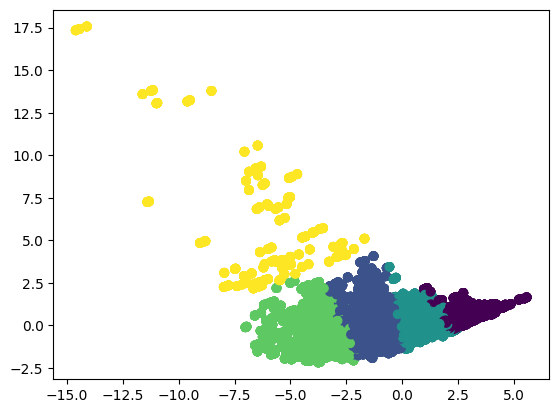

In [26]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"])
plt.show()

\*\*\*

La cantidad óptima de k usando lel elbow plot: 

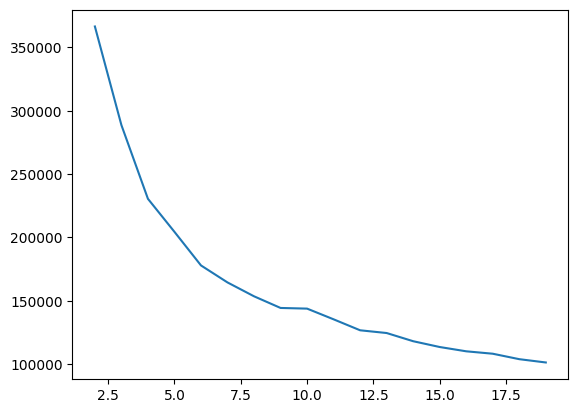

In [34]:
inertia = []

for k in range(2,20):
    km = KMeans(n_clusters=k)
    km.fit(df_clustering_scaled)
    inertia.append(km.inertia_)

plt.plot(list(range(2,20)), inertia); 